# Movie Cytoplasm Height Boxplot

This notebook plots `cytoplasm_height_movie_summary.csv` as a boxplot grouped by `group`, with individual movie samples overlaid.

In [16]:
# # Regenerate summary CSV from per-movie measurements
# !python scripts/analysis/summarize_movie_cytoplasm_height.py \
#     --input-root results/movie_cytoplasm_width/Hermetia/ \
#     --out-csv results/movie_cytoplasm_width/Hermetia/cytoplasm_height_movie_summary.csv

In [17]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind

csv_path = Path("results/movie_cytoplasm_width/Hermetia/cytoplasm_height_movie_summary.csv")
df = pd.read_csv(csv_path)
df.head()

,group,movie_id,movie_path,n_x_valid,mean_cytoplasm_height_px,mean_cytoplasm_height_um
0,centrifugation_dorsal,1,centrifugation/dorsal/1,194,91.2732,24.9915
1,centrifugation_dorsal,2,centrifugation/dorsal/2,1169,96.3482,26.3810
2,centrifugation_dorsal,3,centrifugation/dorsal/3,194,112.6390,30.8417
3,centrifugation_dorsal,4,centrifugation/dorsal/4,194,106.1080,29.0534
4,centrifugation_dorsal,5,centrifugation/dorsal/5,1169,98.3610,26.9322


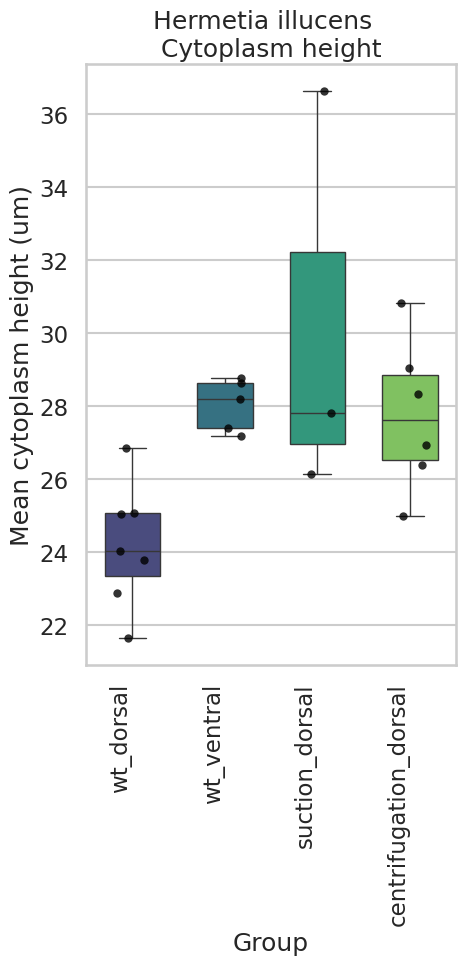

In [18]:
metric_col = "mean_cytoplasm_height_um"

# Put conditions in requested left-to-right order: wt, suction, centrifugation.
prefix_order = ["wt", "suction", "centrifugation"]
groups = sorted(df["group"].unique())
group_order = []
for prefix in prefix_order:
    group_order.extend([g for g in groups if g.startswith(f"{prefix}_")])
group_order.extend([g for g in groups if g not in group_order])

palette = dict(zip(group_order, sns.color_palette("viridis", n_colors=len(group_order))))

# Pairwise Welch t-tests between groups (disabled for now)
# pvals = []
# for g1, g2 in combinations(group_order, 2):
#     x1 = df.loc[df["group"] == g1, metric_col]
#     x2 = df.loc[df["group"] == g2, metric_col]
#     stat, pval = ttest_ind(x1, x2, equal_var=False)
#     pvals.append({"group_1": g1, "group_2": g2, "p_value": pval})
#
# pvals_df = pd.DataFrame(pvals).sort_values("p_value")
# display(pvals_df)

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(5, 10))

sns.boxplot(
    data=df,
    x="group",
    y=metric_col,
    order=group_order,
    hue="group",
    palette=palette,
    dodge=False,
    showfliers=False,
    width=0.6,
    legend=False,
    ax=ax,
)

sns.stripplot(
    data=df,
    x="group",
    y=metric_col,
    order=group_order,
    color="black",
    alpha=0.8,
    size=6,
    jitter=0.18,
    ax=ax,
)

# Statistical annotation block (disabled for now)
# def p_to_asterisks(p_value):
#     if p_value < 1e-4:
#         return "****"
#     if p_value < 1e-3:
#         return "***"
#     if p_value < 1e-2:
#         return "**"
#     if p_value < 0.05:
#         return "*"
#     return "ns"
#
# y_min = df[metric_col].min()
# y_max = df[metric_col].max()
# y_range = y_max - y_min
# base_y = y_max + 0.12 * y_range
# step = 0.10 * y_range
#
# for i, row in pvals_df.iterrows():
#     x1 = group_order.index(row["group_1"])
#     x2 = group_order.index(row["group_2"])
#     y = base_y + i * step
#
#     ax.plot([x1, x1, x2, x2], [y - 0.02 * y_range, y, y, y - 0.02 * y_range], color="black", lw=1.2)
#     ax.text(
#         (x1 + x2) / 2,
#         y + 0.01 * y_range,
#         p_to_asterisks(row["p_value"]),
#         ha="center",
#         va="bottom",
#         fontsize=12,
#     )
ax.set_xlabel("Group")
ax.set_ylabel("Mean cytoplasm height (um)")
ax.set_title("Hermetia illucens  \n Cytoplasm height ")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()